# **Project Name**    - PRCP-1026-Teaching Assistance



##### **Project Type**    - Multi class Classification(EDA + Ml model)
##### **Contribution**    - Individual
##### ** Member 1 -**     _ K.JEBASINGH PRAVEEN
##### **  project ID **   - PTID-CDS-DEC-25-3614

# **Project Summary -**

This project involves the end-to-end development of a machine learning solution to predict teaching assistant class performance using a structured educational dataset. The dataset includes features such as teacher nativeness, instructor identity, course type, semester, class size.

# **GitHub Link -**

Provide your GitHub Link here.

# **Problem Statement**


Educational institutions aim to continuously improve teaching quality and learning outcomes. However, class performance is influenced by multiple factors such as instructor characteristics, course type, semester, and class size. Manually evaluating these factors and predicting class effectiveness is time-consuming and prone to subjectivity.

The objective of this project is to build a machine learning–based classification model that predicts the Class Attribute (Low, Medium, High) using historical teaching evaluation data. By leveraging data-driven insights, the model aims to assist institutions in understanding key factors affecting class quality and enabling proactive academic decision-making.

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















# ***Let's Begin !***

### TASK:1

## ***1. Know Your Data***

### Import Libraries

In [667]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D

import warnings
warnings.filterwarnings("ignore")

### Dataset Loading

In [668]:
# Load Dataset
data = pd.read_csv('tae.csv') # The insurance cost data in csv is stored in the variable of data

### Dataset First View

In [669]:
# Dataset First Look
data.head()      # .head() function shows the first five rows of the dataframe

,Native_Teacher,Instructor,Course,Semester,Class_Size,Class_Attribute
0,1,23,3,1,19,3
1,2,15,3,1,17,3
2,1,23,3,2,49,3
3,1,5,2,2,33,3
4,2,7,11,2,55,3


In [670]:
data.tail()  #.tail() function shows the last five rows of the dataframe

,Native_Teacher,Instructor,Course,Semester,Class_Size,Class_Attribute
146,2,3,2,2,26,1
147,2,10,3,2,12,1
148,1,18,7,2,48,1
149,2,22,1,2,51,1
150,2,2,10,2,27,1


### Dataset Rows & Columns count

In [671]:
# Dataset Rows & Columns count
data.shape  # the dataset contains 151 Rows and 6 columns

(151, 6)

### Dataset Information

In [672]:
# Dataset Info
data.info()  # it provides nuber of non-null entries,data types and memory usage

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 151 entries, 0 to 150
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Native_Teacher   151 non-null    int64
 1   Instructor       151 non-null    int64
 2   Course           151 non-null    int64
 3   Semester         151 non-null    int64
 4   Class_Size       151 non-null    int64
 5   Class_Attribute  151 non-null    int64
dtypes: int64(6)
memory usage: 7.2 KB


#### Duplicate Values

In [673]:
#check duplicate values in the columns
data.columns.duplicated()   # it indicates as False so no duplicate columns in the dataset

array([False, False, False, False, False, False])

In [674]:
# Dataset Duplicate Value Count in the row
data.duplicated().sum()

np.int64(41)

In [675]:
#Removing duplicates
data = data.drop_duplicates()

In [676]:
data.duplicated().sum()  # rechecking after applying the code of drop_duplicates
                         # it shows zero so no duplicate values in the dataset

np.int64(0)

In [677]:
data.reset_index(drop=True, inplace=True)
#  it resets the dataframe index to a clean sequential order, removes the old index without creating an extra column, 
#   and updates the dataframe in place.

In [678]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110 entries, 0 to 109
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Native_Teacher   110 non-null    int64
 1   Instructor       110 non-null    int64
 2   Course           110 non-null    int64
 3   Semester         110 non-null    int64
 4   Class_Size       110 non-null    int64
 5   Class_Attribute  110 non-null    int64
dtypes: int64(6)
memory usage: 5.3 KB


#### Missing Values/Null Values

In [679]:
# Missing Values/Null Values Count
data.isnull().sum()  # .isnull..>identifies missing values (returns True/False) .sum..>Counts True values
                     # Each column represents the value of zero so no null values

Native_Teacher     0
Instructor         0
Course             0
Semester           0
Class_Size         0
Class_Attribute    0
dtype: int64

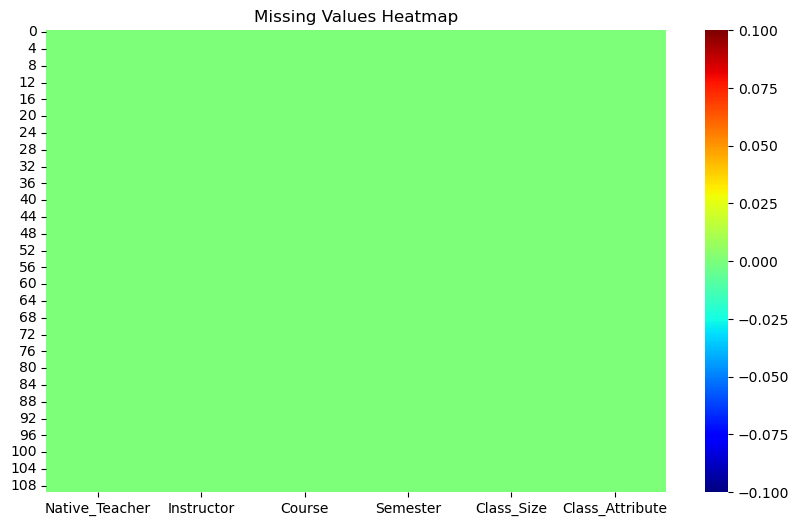

In [680]:

# Visualizing the missing values

#set figure size(width=10,height=6)
plt.figure(figsize=(10,6))

sns.heatmap(data.isnull(), cbar=True, cmap="jet") # cbar=True..>it means show the color bar(legend)

# add title 
plt.title("Missing Values Heatmap")

#display the plot
plt.show()

### What did you know about your dataset?

The dataset represents Teaching Assistant (TA) evaluation data collected from different courses and instructors. It aims to analyze how various academic and instructional factors influence the overall class performance rating.

Number of features: 6
Target variable: Class_Attribute
Problem type: Multiclass Classification
Target classes: Low, Medium, High

## ***2. Understanding Your Variables***

In [681]:
# Dataset Columns
data.columns # Here we can see all columns using columns

Index(['Native_Teacher', 'Instructor', 'Course', 'Semester', 'Class_Size',
       'Class_Attribute'],
      dtype='object')

In [682]:
# Dataset Describe
data.describe() # It gives summary statistics 

,Native_Teacher,Instructor,Course,Semester,Class_Size,Class_Attribute
count,110.000000,110.000000,110.000000,110.000000,110.000000,110.000000
mean,1.772727,14.027273,8.145455,1.863636,27.281818,2.018182
std,0.420988,6.780245,7.163665,0.344745,13.141525,0.823751
min,1.000000,1.000000,1.000000,1.000000,3.000000,1.000000
25%,2.000000,9.000000,3.000000,2.000000,18.250000,1.000000
50%,2.000000,14.000000,3.500000,2.000000,25.000000,2.000000
75%,2.000000,20.000000,15.000000,2.000000,37.000000,3.000000
max,2.000000,25.000000,26.000000,2.000000,66.000000,3.000000


### Variables Description

Native_Teacher	- Categorical (Binary) :	Indicates whether the teaching assistant is a native English speaker. 1 = Native English speaker, 2 = Non-native English speaker.

Instructor	- Categorical  :Identifies the course instructor. The dataset contains 25 unique instructors, each representing different teaching styles and experience levels.

Course	- Categorical :	Represents the course being taught. There are 26 distinct courses, capturing subject-wise variations in teaching and evaluation.

Semester	- Categorical (Binary) :	Indicates the academic term. 1 = Summer semester, 2 = Regular semester.

Class_Size	- Numerical :	Number of students enrolled in the class session. Reflects class scale and student-to-instructor interaction level.

Class_Attribute	- Ordinal Categorical (Target Variable):Overall evaluation of the class performance. 1 = Low, 2 = Medium, 3 = High.

### Check Unique Values for each variable.

In [683]:
# Check Unique Values for each variable.
for col in data.columns:         # Loops through each column name in the DataFrame
    print(f"\nColumn: {col}")    # Prints the column name
    print(data[col].unique())    # Prints the unique values in the each column.


Column: Native_Teacher
[1 2]

Column: Instructor
[23 15  5  7  9 10 22 13 18  6 25  2  1  8 14 21 11 16  4 17 20 12 24  3
 19]

Column: Course
[ 3  2 11  5 22  1 21 17 25  7  9 15 13  8 16 19 14  6 12 18 23 26 24 20
  4 10]

Column: Semester
[1 2]

Column: Class_Size
[19 17 49 33 55 20 27 58  9 30 29 39 42 43 10 46 23 31 22 37 13 24 38 28
 51 36 21 48 25 11 45 18 14 35 15 32 34 66 12  3  7 54 16 44  5 26]

Column: Class_Attribute
[3 2 1]


In [684]:
# Check Unique Values for each variable.
data.nunique()   # count of unique values in a column.

Native_Teacher      2
Instructor         25
Course             26
Semester            2
Class_Size         46
Class_Attribute     3
dtype: int64

## 3. ***Data Wrangling***

### Data Wrangling Code

In [685]:
# Write your code to make your dataset analysis ready.
data.head()

,Native_Teacher,Instructor,Course,Semester,Class_Size,Class_Attribute
0,1,23,3,1,19,3
1,2,15,3,1,17,3
2,1,23,3,2,49,3
3,1,5,2,2,33,3
4,2,7,11,2,55,3


### What all manipulations have you done and insights you found?

I found that more duplicate rows are there and no null values and i have removed duplicate rows

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1 Density Plot

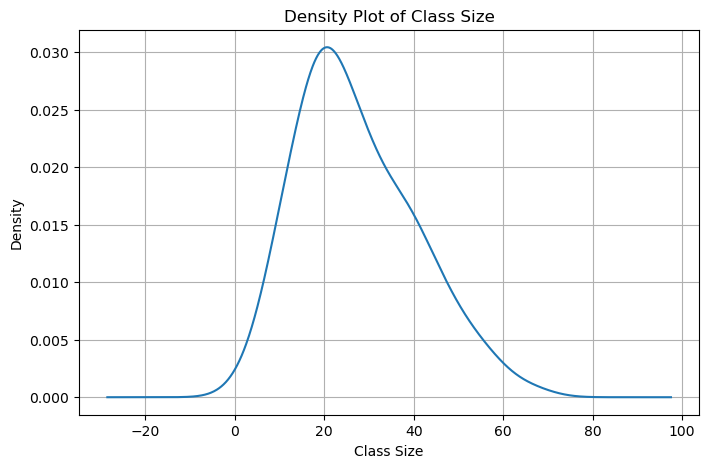

In [686]:
# Chart - 1 visualization code
# Density plot for Class_Size
plt.figure(figsize=(8, 5))
data["Class_Size"].plot(kind="density")
plt.title("Density Plot of Class Size")
plt.xlabel("Class Size")
plt.ylabel("Density")
plt.grid(True)
plt.show()

##### 1. Why did you pick the specific chart?

Class_Size is a numerical continuous variable

A density plot is ideal to:
Understand the distribution shape
Identify skewness
Observe where values are concentrated

##### 2. What is/are the insight(s) found from the chart?

Most classes are concentrated around a specific size range
The distribution is slightly skewed, indicating

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Maintain optimal class sizes for better learning outcomes
Avoid overcrowded classes that reduce teaching effectiveness

#### Chart - 2 Histogram

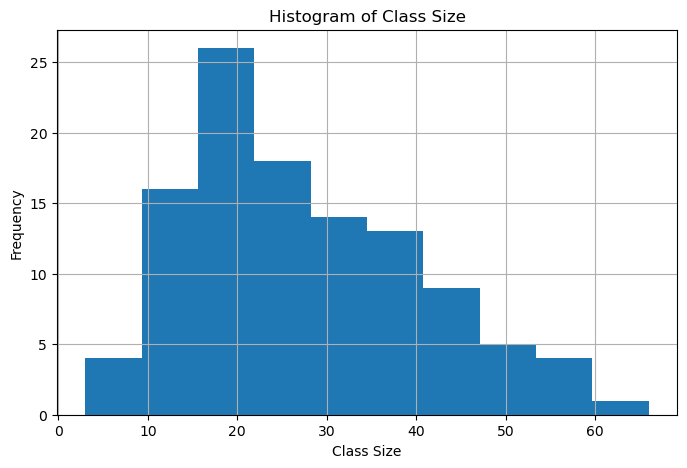

In [687]:
# Chart - 2 visualization code
# Histogram for Class_Size
plt.figure(figsize=(8, 5))
plt.hist(data["Class_Size"], bins=10)
plt.title("Histogram of Class Size")
plt.xlabel("Class Size")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

##### 1. Why did you pick the specific chart?

Understanding frequency distribution
Observing data spread
Identifying skewness and concentration.

##### 2. What is/are the insight(s) found from the chart?

Most classes fall into mid-range size bins
Very small and very large classes occur less frequently
The distribution is slightly right-skewed
No sudden spikes, indicating consistent class size planning

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Decide ideal enrollment limits
Prevent overcrowding
Improve teaching effectiveness

#### Chart - 3 Count Plot

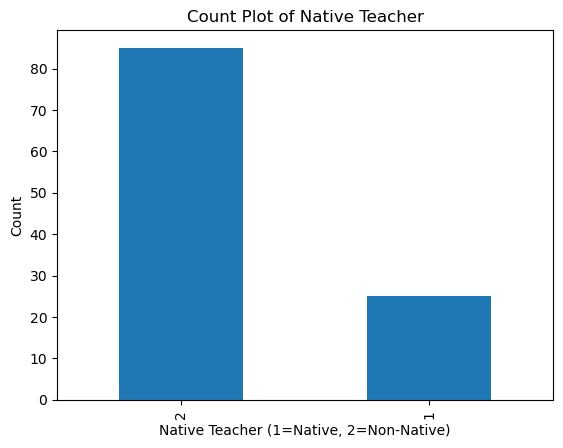

In [688]:
# Chart - 3 visualization code
data["Native_Teacher"].value_counts().plot(kind="bar")
plt.title("Count Plot of Native Teacher")
plt.xlabel("Native Teacher (1=Native, 2=Non-Native)")
plt.ylabel("Count")
plt.show()

##### 1. Why did you pick the specific chart?

Binary categorical variable
Count plot shows class balance clearly


##### 2. What is/are the insight(s) found from the chart?

Shows proportion of native vs non-native English teachers
Helps identify dominance of one group

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Helps institutions evaluate language influence on teaching quality
Useful for training and hiring decisions

#### Chart - 4 Bar Chart

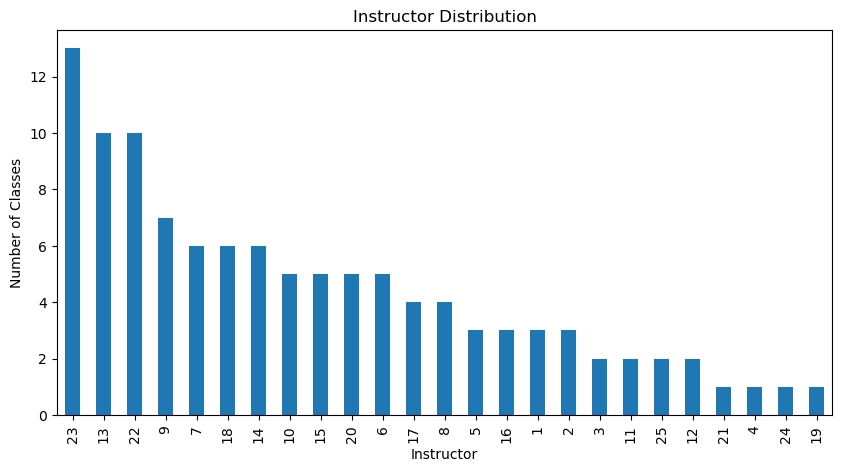

In [689]:
# Chart - 4 visualization code
data["Instructor"].value_counts().plot(kind="bar", figsize=(10,5))
plt.title("Instructor Distribution")
plt.xlabel("Instructor")
plt.ylabel("Number of Classes")
plt.show()


##### 1. Why did you pick the specific chart?

High-cardinality categorical variable
Bar chart shows teaching load distribution

##### 2. What is/are the insight(s) found from the chart?

Some instructors handle more classes than others
Teaching responsibility is unevenly distributed

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Helps in workload balancing
Prevents instructor burnout
Improves teaching quality consistency

#### Chart - 5 Bar Chart

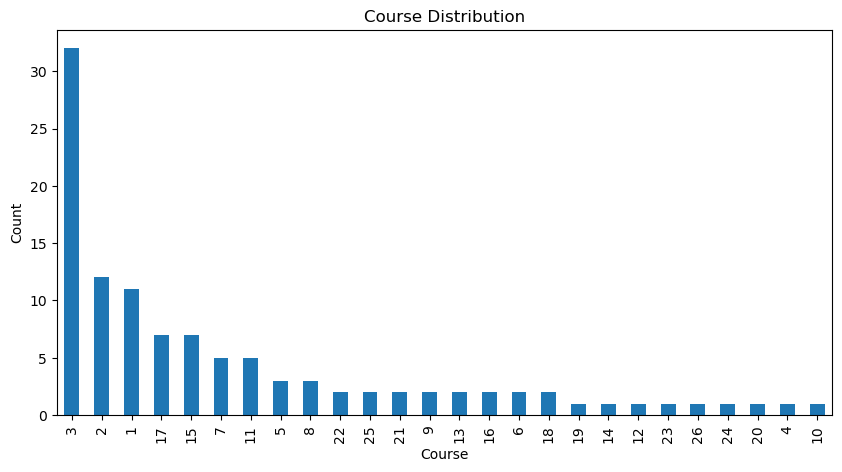

In [690]:
# Chart - 5 visualization code
data["Course"].value_counts().plot(kind="bar", figsize=(10,5))
plt.title("Course Distribution")
plt.xlabel("Course")
plt.ylabel("Count")
plt.show()


##### 1. Why did you pick the specific chart?

Course is categorical
Bar chart helps compare course popularity

##### 2. What is/are the insight(s) found from the chart?

Some courses are offered more frequently
Indicates demand-driven subjects

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Helps universities plan course offerings
Supports resource allocation for popular courses

#### Chart - 6 Count Plot

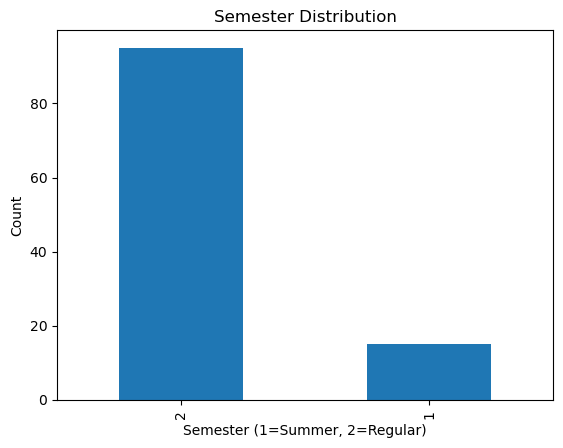

In [691]:
# Chart - 6 visualization code
data["Semester"].value_counts().plot(kind="bar")
plt.title("Semester Distribution")
plt.xlabel("Semester (1=Summer, 2=Regular)")
plt.ylabel("Count")
plt.show()


##### 1. Why did you pick the specific chart?

Binary categorical variable
Count plot shows seasonal distribution

##### 2. What is/are the insight(s) found from the chart?

Regular semesters dominate
Fewer classes conducted in summer

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Helps in academic calendar planning
Supports staffing and scheduling decisions

#### Chart - 7

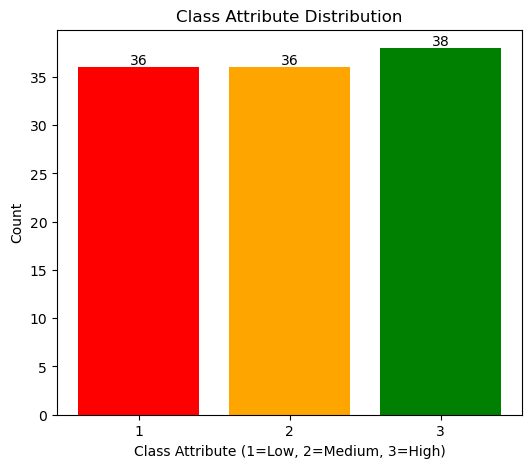

In [692]:
# Chart - 7 visualization code


# Count values and sort by class
counts = data["Class_Attribute"].value_counts().sort_index()

# Custom color mapping
color_map = {
    1: "red",     # Low
    2: "orange",  # Medium
    3: "green"    # High
}

# Apply colors based on class labels
colors = [color_map[class_label] for class_label in counts.index]

# Plot bar chart
plt.figure(figsize=(6, 5))
bars = plt.bar(counts.index.astype(str), counts.values, color=colors)

# Titles and labels
plt.title("Class Attribute Distribution")
plt.xlabel("Class Attribute (1=Low, 2=Medium, 3=High)")
plt.ylabel("Count")

# Add count labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        str(height),
        ha="center",
        va="bottom"
    )

plt.show()


##### 1. Why did you pick the specific chart?

Target variable is categorical
Count plot checks class imbalance

##### 2. What is/are the insight(s) found from the chart?

Shows distribution of Low / Medium / High classes
Helps understand prediction difficulty

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Identifies quality gaps
Enables targeted improvement strategies
Helps institutions raise overall teaching quality

#### Chart - 8 Violin Plot

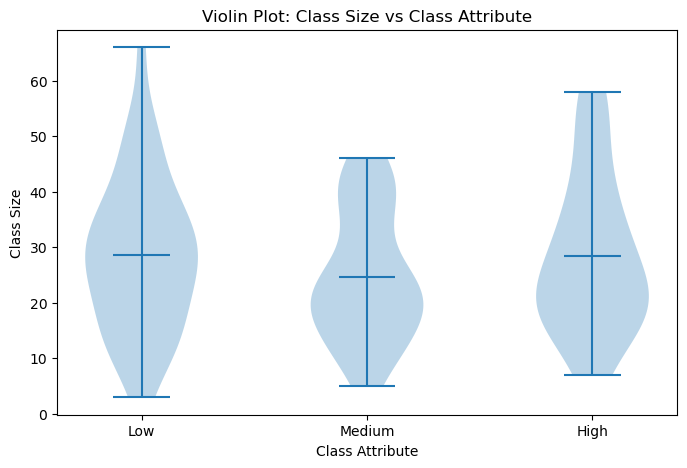

In [693]:
# Chart - 8 visualization code

# Prepare data for violin plot
plot_data = [
    data[data["Class_Attribute"] == 1]["Class_Size"],
    data[data["Class_Attribute"] == 2]["Class_Size"],
    data[data["Class_Attribute"] == 3]["Class_Size"]
]

# Violin plot
plt.figure(figsize=(8, 5))
plt.violinplot(plot_data, showmeans=True)
plt.xticks([1, 2, 3], ["Low", "Medium", "High"])
plt.xlabel("Class Attribute")
plt.ylabel("Class Size")
plt.title("Violin Plot: Class Size vs Class Attribute")
plt.show()


##### 1. Why did you pick the specific chart?

Class_Size is numerical
Class_Attribute is categorical
Shows distribution shape
Displays density + spread
Highlights variation across categories

##### 2. What is/are the insight(s) found from the chart?

Low-rated classes tend to have larger or more variable class sizes

High-rated classes show:
More compact distribution
Moderate class sizes
Medium-rated classes lie in between

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Better student engagement
Improved teaching effectiveness

#### Chart - 9 Bar Plot

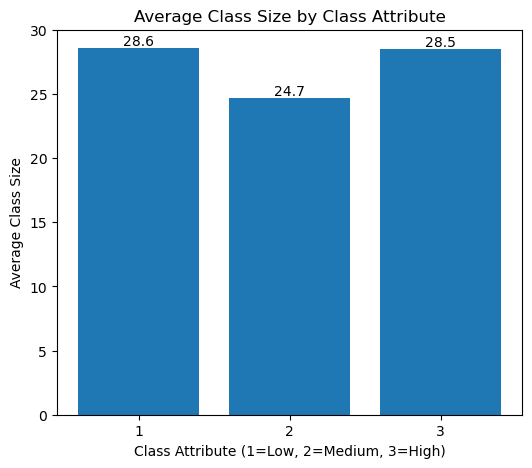

In [694]:
# Chart - 9 visualization code
# Calculate mean class size per class attribute
mean_class_size = data.groupby("Class_Attribute")["Class_Size"].mean()

# Bar plot
plt.figure(figsize=(6, 5))
bars = plt.bar(
    mean_class_size.index.astype(str),
    mean_class_size.values
)

plt.xlabel("Class Attribute (1=Low, 2=Medium, 3=High)")
plt.ylabel("Average Class Size")
plt.title("Average Class Size by Class Attribute")

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        round(height, 1),
        ha="center",
        va="bottom"
    )

plt.show()


##### 1. Why did you pick the specific chart?

Bar plot summarizes numerical data using aggregation
Shows mean class size per performance level
Easy to interpret for non-technical stakeholders

##### 2. What is/are the insight(s) found from the chart?

High-performing classes have optimal average class sizes
Low-performing classes tend to have higher average class sizes

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Enrollment caps
Classroom planning
Instructor allocation

#### Chart - 10 Violin Plot

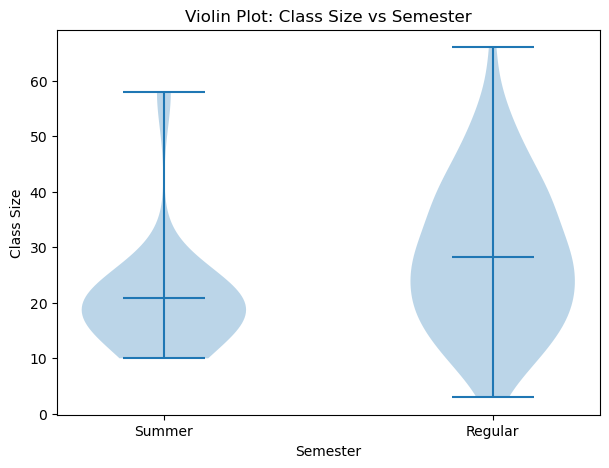

In [695]:
# Chart - 10 visualization code

# Prepare data for violin plot
summer_class_size = data[data["Semester"] == 1]["Class_Size"]
regular_class_size = data[data["Semester"] == 2]["Class_Size"]

violin_data = [summer_class_size, regular_class_size]

# Violin plot
plt.figure(figsize=(7, 5))
plt.violinplot(violin_data, showmeans=True)
plt.xticks([1, 2], ["Summer", "Regular"])
plt.xlabel("Semester")
plt.ylabel("Class Size")
plt.title("Violin Plot: Class Size vs Semester")
plt.show()


##### 1. Why did you pick the specific chart?

One variable is numerical (Class_Size)
The other is categorical (Semester)
Shows full distribution shape
Highlights spread and variability
Compares distributions across categories

##### 2. What is/are the insight(s) found from the chart?

Summer semester classes:
  Tend to have smaller and tighter distributions
Regular semester classes:
  Show larger and more varied class sizes  

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Plan enrollment caps per semester
Optimize resource allocation
Improve student–teacher interaction
Enables smarter semester-wise academic planning

#### Chart - 11 Bar Plot

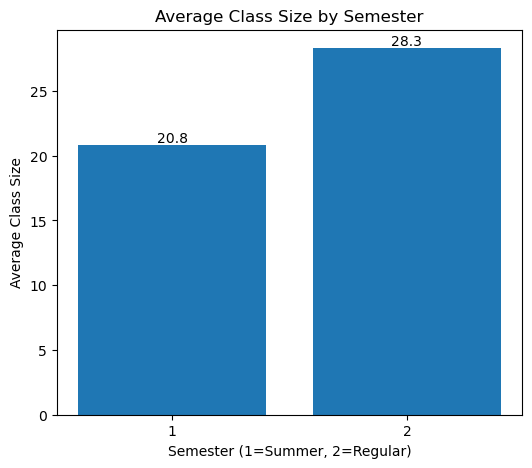

In [696]:
# Chart - 11 visualization code
# Calculate average class size per semester
avg_class_size = data.groupby("Semester")["Class_Size"].mean()

# Bar plot
plt.figure(figsize=(6, 5))
bars = plt.bar(
    avg_class_size.index.astype(str),
    avg_class_size.values
)

plt.xlabel("Semester (1=Summer, 2=Regular)")
plt.ylabel("Average Class Size")
plt.title("Average Class Size by Semester")

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        round(height, 1),
        ha="center",
        va="bottom"
    )

plt.show()


##### 1. Why did you pick the specific chart?

Bar plot summarizes numerical data using mean aggregation
Easy to interpret for academic and business stakeholders
Clearly compares semester-wise averages

##### 2. What is/are the insight(s) found from the chart?

Regular semester has a higher average class size
smmer semester maintains smaller classes

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Faculty staffing decisions
Classroom capacity planning
Budget and infrastructure planning
Helps improve teaching quality by controlling class size

#### Chart - 12 Grouped Bar Chart

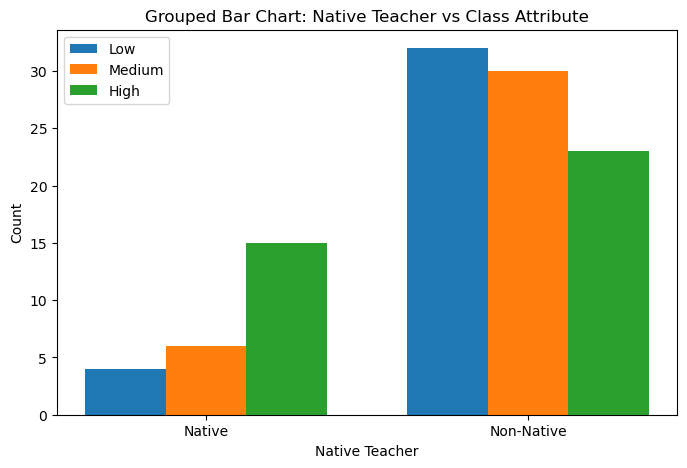

In [697]:
# Chart - 12 visualization code

# Create a contingency table
grouped_counts = pd.crosstab(data["Native_Teacher"], data["Class_Attribute"])

# X locations and bar width
x = np.arange(len(grouped_counts.index))
width = 0.25

# Plot grouped bars
plt.figure(figsize=(8, 5))
plt.bar(x - width, grouped_counts[1], width, label="Low")
plt.bar(x, grouped_counts[2], width, label="Medium")
plt.bar(x + width, grouped_counts[3], width, label="High")

# Labels and title
plt.xlabel("Native Teacher")
plt.ylabel("Count")
plt.title("Grouped Bar Chart: Native Teacher vs Class Attribute")
plt.xticks(x, ["Native", "Non-Native"])
plt.legend()

plt.show()


##### 1. Why did you pick the specific chart?

Allows side-by-side comparison
Clearly shows how Class_Attribute varies across Native_Teacher categories
Best choice to analyze category-to-category relationships

##### 2. What is/are the insight(s) found from the chart?

Native English teachers tend to have:
  Higher counts in Medium and High class attributes
Non-native teachers show:
  Slightly higher proportion of Low class attributes
Language proficiency appears to influence teaching evaluation  

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Identify areas for language-focused training
Provide communication skill development for non-native teachers

#### Chart - 13 Stacked Bar Chart

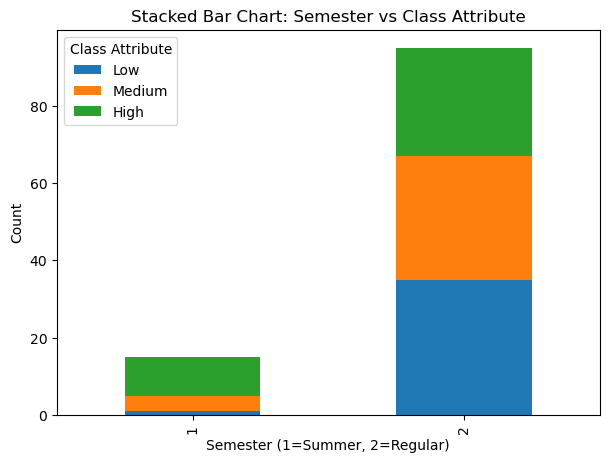

In [698]:
# Chart - 13 visualization code

# Create contingency table
stacked_data = pd.crosstab(data["Semester"], data["Class_Attribute"])

# Plot stacked bar chart
stacked_data.plot(
    kind="bar",
    stacked=True,
    figsize=(7, 5)
)

# Labels and title
plt.xlabel("Semester (1=Summer, 2=Regular)")
plt.ylabel("Count")
plt.title("Stacked Bar Chart: Semester vs Class Attribute")
plt.legend(title="Class Attribute", labels=["Low", "Medium", "High"])
plt.show()


##### 1. Why did you pick the specific chart?

Shows overall volume per semester
Displays composition of class performance levels
Helps compare distribution proportions within each semester

##### 2. What is/are the insight(s) found from the chart?

Regular semester:
Has a higher total number of classes
Shows a larger share of Medium and High performance classes

Summer semester:
Has fewer classes overall
Lower proportion of High performance classes

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Focus quality improvement initiatives during summer semesters
Allocate experienced instructors strategically

### Chart - 14 - Strip Plot

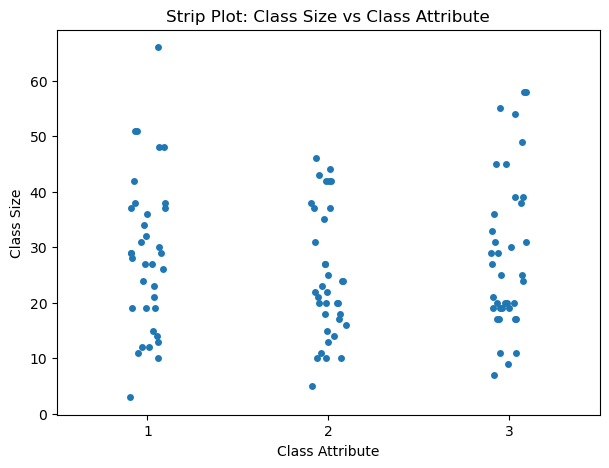

In [699]:
# visualization code

plt.figure(figsize=(7,5))
sns.stripplot(
    x="Class_Attribute",
    y="Class_Size",
    data=data,
    jitter=True
)

plt.title("Strip Plot: Class Size vs Class Attribute")
plt.xlabel("Class Attribute")
plt.ylabel("Class Size")
plt.show()


1. Why did you pick the specific chart?

2. What is/are the insight(s) found from the chart?

3. Will the gained insights help creating a positive business impact?

### Chart - 15 - Swarm Plot

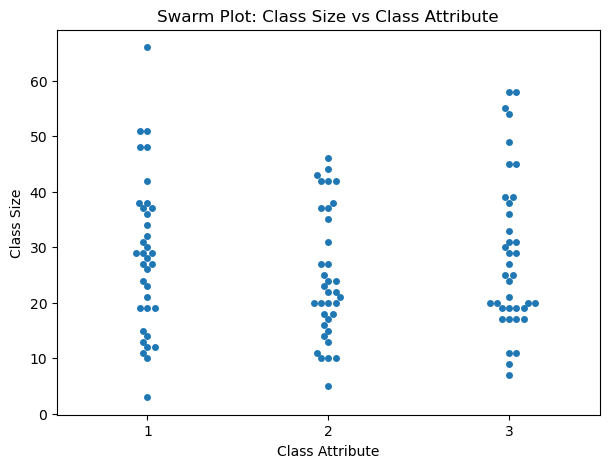

In [700]:
# visualization code
plt.figure(figsize=(7,5))
sns.swarmplot(
    x="Class_Attribute",
    y="Class_Size",
    data=data
)

plt.title("Swarm Plot: Class Size vs Class Attribute")
plt.xlabel("Class Attribute")
plt.ylabel("Class Size")
plt.show()


1.Why did you pick the specific chart?

Improves over strip plot by avoiding point overlap
Shows density and clustering clearly
Best for small-to-medium datasets

2.What is/are the insight(s) found from the chart?

3.Will the gained insights help creating a positive business impact?

### Chart - 16 - Joint Plot

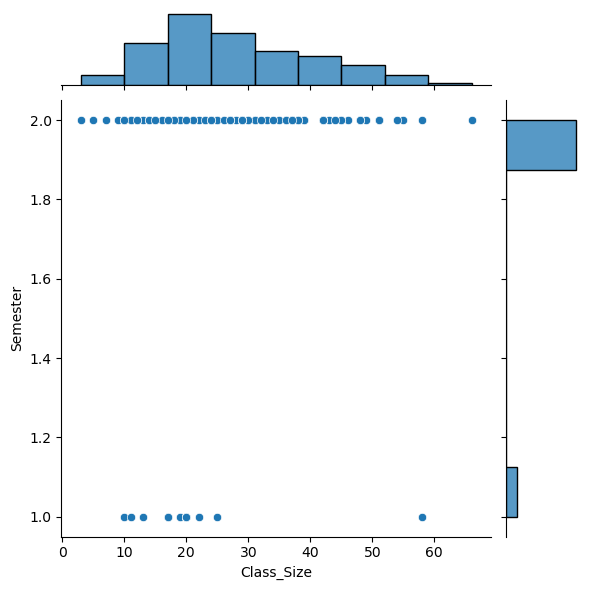

In [701]:
# visualization code
sns.jointplot(
    x="Class_Size",
    y="Semester",
    data=data,
    kind="scatter"
)

plt.show()


1.Why did you pick the specific chart?

2.What is/are the insight(s) found from the chart?

3.Will the gained insights help creating a positive business impact?

#### Chart - 17 - Correlation Heatmap

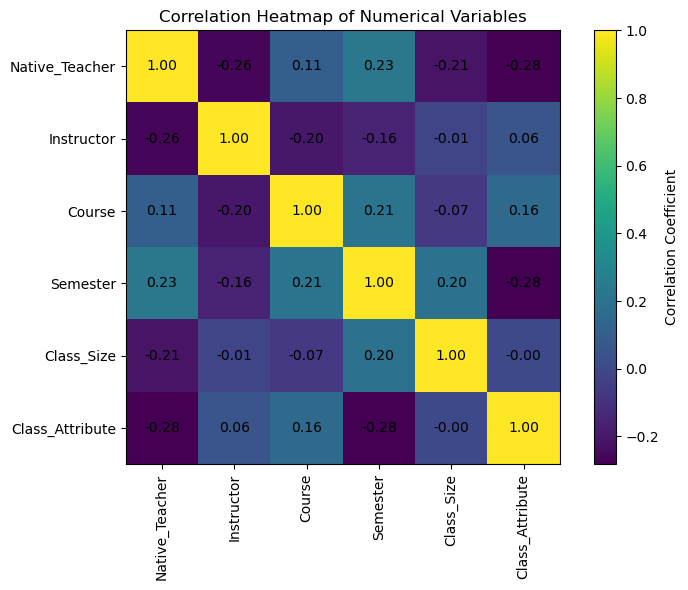

In [702]:
# Correlation Heatmap visualization code

# Select numerical columns
num_data = data.select_dtypes(include=['int64', 'float64'])

# Compute correlation matrix
corr = num_data.corr()

# Plot heatmap
plt.figure(figsize=(8, 6))
plt.imshow(corr)
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(j, i, f"{corr.iloc[i, j]:.2f}",
                 ha="center", va="center", color="black")

plt.colorbar(label='Correlation Coefficient')

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Heatmap of Numerical Variables")
plt.tight_layout()
plt.show()




##### 1. Why did you pick the specific chart?

Identify important predictors
Detect multicollinearity
Support feature selection before ML modeling

##### 2. What is/are the insight(s) found from the chart?

Semester vs Class_Size (≈ +0.27)
 Slight positive correlation
 Regular semesters tend to have larger class sizes

Native_Teacher vs Class_Attribute (≈ -0.25)
 Moderate negative relationship
 Suggests class quality perception may differ based on native/non-native teachers

Semester vs Class_Attribute (≈ -0.28)
 Indicates class attribute distribution varies by semester

Class_Size vs Class_Attribute (≈ -0.03)
 Almost no correlation
 Class size alone does not strongly determine class quality

No strong correlations (> 0.7)
 Indicates low multicollinearity


#### Chart - 18 - Pair Plot

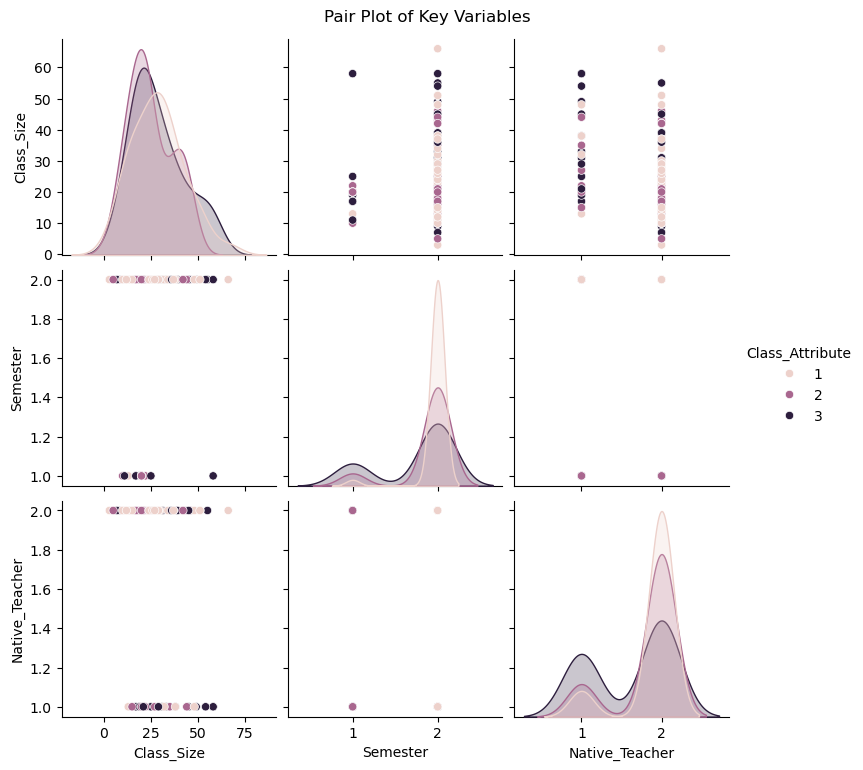

In [703]:
# Pair Plot visualization code
# Select relevant columns for pair plot
pairplot_data = data[[
    "Class_Size",
    "Semester",
    "Native_Teacher",
    "Class_Attribute"
]]

# Create pair plot
sns.pairplot(
    pairplot_data,
    hue="Class_Attribute",
    diag_kind="kde"
)

plt.suptitle("Pair Plot of Key Variables", y=1.02)
plt.show()


##### 1. Why did you pick the specific chart?

Simultaneous comparison of multiple variables
Visualization of pairwise relationships
Distribution analysis using KDE plots



##### 2. What is/are the insight(s) found from the chart?

Answer Here

#### Chart - 19 - 3D Scatter Plot

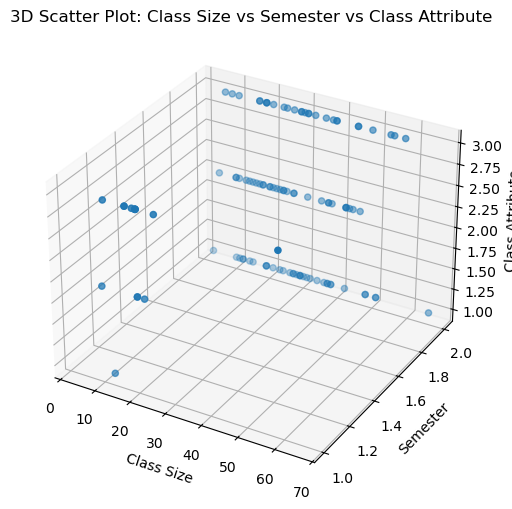

In [704]:
# visualization code

# Create 3D scatter plot
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    data["Class_Size"],
    data["Semester"],
    data["Class_Attribute"]
)

ax.set_xlabel("Class Size")
ax.set_ylabel("Semester")
ax.set_zlabel("Class Attribute")
ax.set_title("3D Scatter Plot: Class Size vs Semester vs Class Attribute")

plt.show()


1. Why did you pick the specific chart?

#### Chart - 20 - Bubble Chart

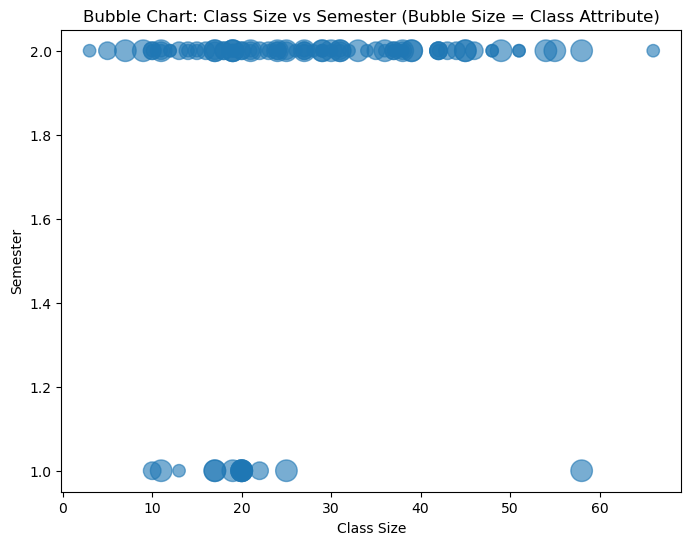

In [705]:
# visualization code

plt.figure(figsize=(8,6))

plt.scatter(
    data["Class_Size"],
    data["Semester"],
    s=data["Class_Attribute"] * 80,  # Bubble size
    alpha=0.6
)

plt.xlabel("Class Size")
plt.ylabel("Semester")
plt.title("Bubble Chart: Class Size vs Semester (Bubble Size = Class Attribute)")

plt.show()


1. Why did you pick the specific chart?

2. What is/are the insight(s) found from the chart?

## ***5. Hypothesis Testing***

### Based on your chart experiments, define three hypothetical statements from the dataset. In the next three questions, perform hypothesis testing to obtain final conclusion about the statements through your code and statistical testing.

We define three hypothetical statements derived from EDA visualizations and test them statistically.

### Hypothetical Statement - 1

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Null Hypothesis (H₀):
There is no significant difference in class size between Summer and Regular semesters.

Alternative Hypothesis (H₁):
There is a significant difference in class size between Summer and Regular semesters.

#### 2. Perform an appropriate statistical test.

In [706]:
# Perform Statistical Test to obtain P-Value
from scipy.stats import ttest_ind

summer = data[data["Semester"] == 1]["Class_Size"]
regular = data[data["Semester"] == 2]["Class_Size"]

t_stat, p_value = ttest_ind(summer, regular, equal_var=False)
p_value


np.float64(0.027243176694819828)

##### Which statistical test have you done to obtain P-Value?

Independent Two-Sample t-test

##### Why did you choose the specific statistical test?

Dependent variable: Class_Size (numerical)
Independent variable: Semester (binary categorical)
Compares means of two independent groups

### Hypothetical Statement - 2

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Null Hypothesis (H₀):
Mean class size is the same across all class attribute levels.

Alternative Hypothesis (H₁):
At least one class attribute group has a different mean class size.

#### 2. Perform an appropriate statistical test.

In [707]:
# Perform Statistical Test to obtain P-Value
from scipy.stats import f_oneway

low = data[data["Class_Attribute"] == 1]["Class_Size"]
medium = data[data["Class_Attribute"] == 2]["Class_Size"]
high = data[data["Class_Attribute"] == 3]["Class_Size"]

f_stat, p_value = f_oneway(low, medium, high)
p_value


np.float64(0.3575969853655095)

##### Which statistical test have you done to obtain P-Value?

One-Way ANOVA

##### Why did you choose the specific statistical test?

One numerical variable (Class_Size)
One categorical variable with more than two groups
Tests mean differences across multiple groups

### Hypothetical Statement - 3

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Null Hypothesis (H₀):
Native teacher status and class attribute are independent.

Alternative Hypothesis (H₁):
Native teacher status and class attribute are associated.

#### 2. Perform an appropriate statistical test.

In [708]:
# Perform Statistical Test to obtain P-Value
from scipy.stats import chi2_contingency

contingency = pd.crosstab(data["Native_Teacher"], data["Class_Attribute"])
chi2, p_value, dof, expected = chi2_contingency(contingency)
p_value


np.float64(0.008283142515449572)

##### Which statistical test have you done to obtain P-Value?

Chi-Square Test of Independence

##### Why did you choose the specific statistical test?

Both variables are categorical
Tests association between two categorical variables

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

#### What all missing value imputation techniques have you used and why did you use those techniques?

Answer Here.

### 2. Handling Outliers

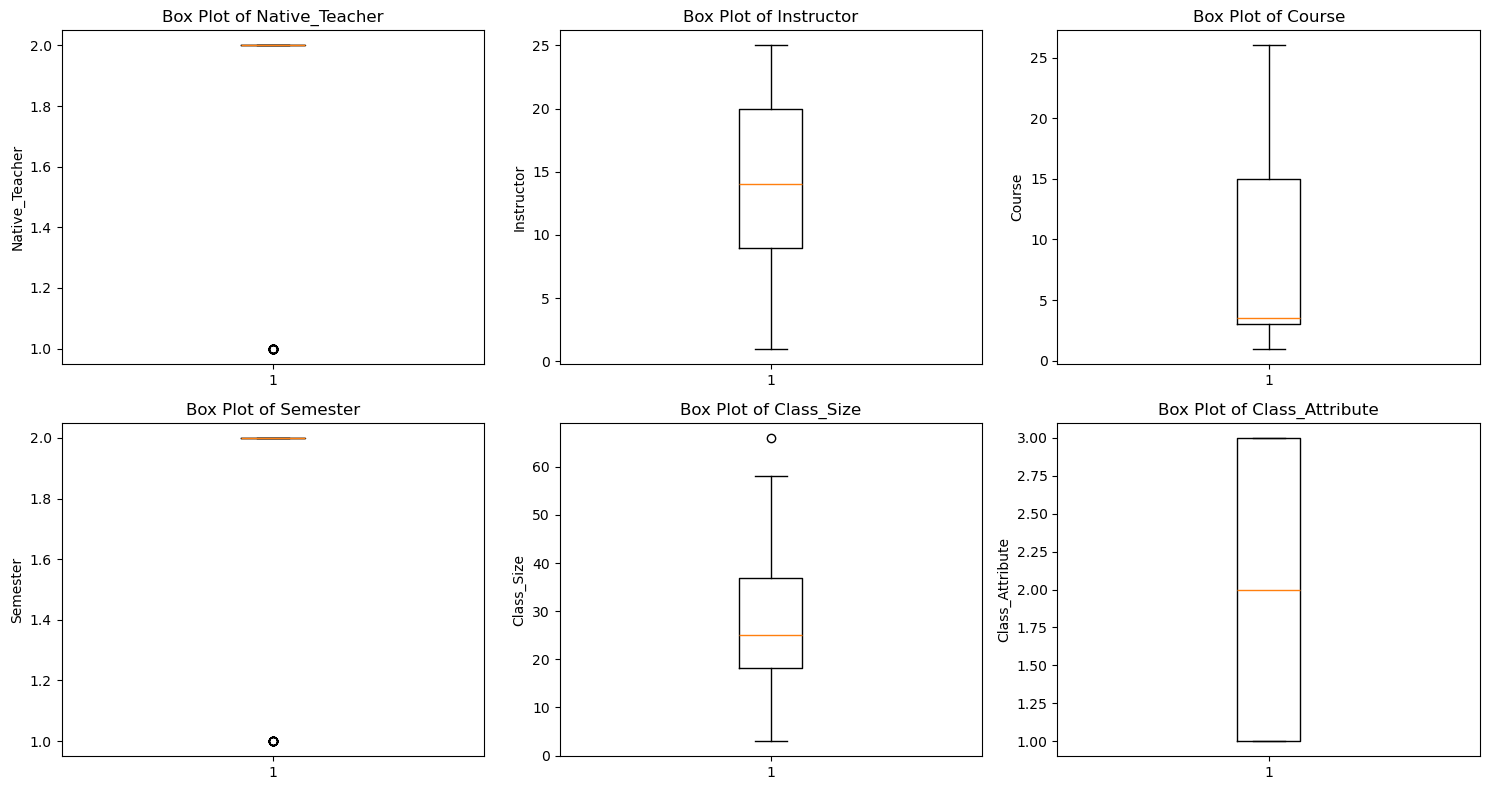

In [709]:
# outliers dection using boxplot
import math

# Select numerical columns
num_cols = data.select_dtypes(include=['int64', 'float64']).columns

# Grid size
cols_per_row = 3
rows = math.ceil(len(num_cols) / cols_per_row)

fig, axes = plt.subplots(rows, cols_per_row, figsize=(15, 4 * rows))
axes = axes.flatten()

# Plot each boxplot
for i, col in enumerate(num_cols):
    axes[i].boxplot(data[col], vert=True)
    axes[i].set_title(f"Box Plot of {col}")
    axes[i].set_ylabel(col)

# Remove empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()



In [710]:
# Handling Outliers & Outlier treatments

# Select Class_Size column
class_size = data["Class_Size"]

# Calculate Q1, Q3, and IQR
Q1 = class_size.quantile(0.25)
Q3 = class_size.quantile(0.75)
IQR = Q3 - Q1

# Define bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Detect outliers
outliers = data[(class_size < lower_bound) | (class_size > upper_bound)]

# Display results
print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)
print("Number of Outliers:", outliers.shape[0])


Q1: 18.25
Q3: 37.0
IQR: 18.75
Lower Bound: -9.875
Upper Bound: 65.125
Number of Outliers: 1


In [711]:
# Remove outliers
new_data = data[
    (data["Class_Size"] >= lower_bound) &
    (data["Class_Size"] <= upper_bound)
]

# Compare shapes
print("Original dataset shape:", data.shape)
print("After removing outliers:", new_data.shape)

Original dataset shape: (110, 6)
After removing outliers: (109, 6)


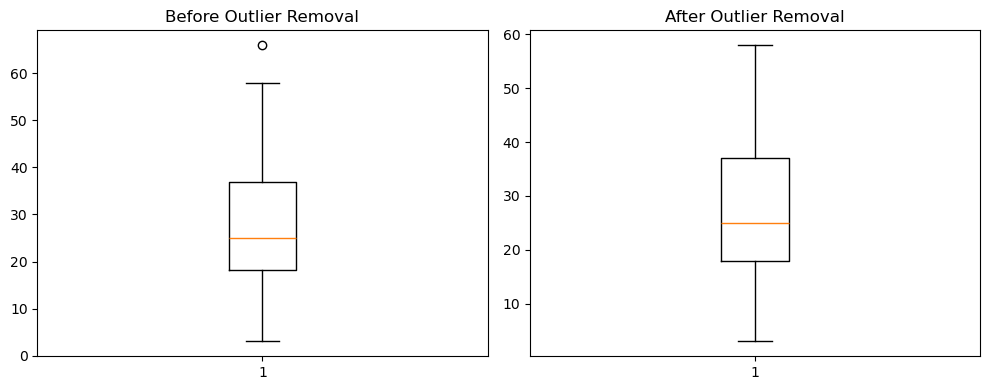

In [712]:
# Visual Comparison (Before vs After)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.boxplot(data["Class_Size"])
plt.title("Before Outlier Removal")

plt.subplot(1,2,2)
plt.boxplot(new_data["Class_Size"])
plt.title("After Outlier Removal")

plt.tight_layout()
plt.show()


##### What all outlier treatment techniques have you used and why did you use those techniques?

IQR Method

Robust to skewed distributions
Does not assume normality
Ideal for real-world numerical data

In [713]:
new_data.reset_index(drop=True, inplace=True)
#  it resets the dataframe index to a clean sequential order, removes the old index without creating an extra column, 
#   and updates the dataframe in place.

In [714]:
new_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109 entries, 0 to 108
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Native_Teacher   109 non-null    int64
 1   Instructor       109 non-null    int64
 2   Course           109 non-null    int64
 3   Semester         109 non-null    int64
 4   Class_Size       109 non-null    int64
 5   Class_Attribute  109 non-null    int64
dtypes: int64(6)
memory usage: 5.2 KB


### 3. Categorical Encoding

#### What all categorical encoding techniques have you used & why did you use those techniques?

Answer Here.

### 4. Textual Data Preprocessing
(It's mandatory for textual dataset i.e., NLP, Sentiment Analysis, Text Clustering etc.)

#### 1. Expand Contraction

In [715]:
# Expand Contraction

#### 2. Lower Casing

In [716]:
# Lower Casing

#### 3. Removing Punctuations

In [717]:
# Remove Punctuations

#### 4. Removing URLs & Removing words and digits contain digits.

In [718]:
# Remove URLs & Remove words and digits contain digits

#### 5. Removing Stopwords & Removing White spaces

In [719]:
# Remove Stopwords

In [720]:
# Remove White spaces

#### 6. Rephrase Text

In [721]:
# Rephrase Text

#### 7. Tokenization

In [722]:
# Tokenization

#### 8. Text Normalization

In [723]:
# Normalizing Text (i.e., Stemming, Lemmatization etc.)

##### Which text normalization technique have you used and why?

Answer Here.

#### 9. Part of speech tagging

In [724]:
# POS Taging

#### 10. Text Vectorization

In [725]:
# Vectorizing Text

##### Which text vectorization technique have you used and why?

Answer Here.

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [726]:
# Manipulate Features to minimize feature correlation and create new features
new_data.corr()['Class_Attribute'].sort_values()

Semester          -0.279600
Native_Teacher    -0.275124
Class_Size         0.034908
Instructor         0.059471
Course             0.151591
Class_Attribute    1.000000
Name: Class_Attribute, dtype: float64

In [727]:
# create interaction feature
new_data["Teacher_Semester"] = (
    new_data["Native_Teacher"].astype(str) + "_" + new_data["Semester"].astype(str)
)


In [728]:
#check whether the new column is created or not
new_data.head()

,Native_Teacher,Instructor,Course,Semester,Class_Size,Class_Attribute,Teacher_Semester
0,1,23,3,1,19,3,1_1
1,2,15,3,1,17,3,2_1
2,1,23,3,2,49,3,1_2
3,1,5,2,2,33,3,1_2
4,2,7,11,2,55,3,2_2


In [729]:
#check the data type of new column
new_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109 entries, 0 to 108
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Native_Teacher    109 non-null    int64 
 1   Instructor        109 non-null    int64 
 2   Course            109 non-null    int64 
 3   Semester          109 non-null    int64 
 4   Class_Size        109 non-null    int64 
 5   Class_Attribute   109 non-null    int64 
 6   Teacher_Semester  109 non-null    object
dtypes: int64(6), object(1)
memory usage: 6.1+ KB


In [730]:
# change the new column'data type
new_data["Teacher_Semester"] = new_data["Teacher_Semester"].astype("category")


In [731]:
new_data["ClassSize_Semester"] = new_data["Class_Size"] * new_data["Semester"]


In [732]:
new_data.head()

,Native_Teacher,Instructor,Course,Semester,Class_Size,Class_Attribute,Teacher_Semester,ClassSize_Semester
0,1,23,3,1,19,3,1_1,19
1,2,15,3,1,17,3,2_1,17
2,1,23,3,2,49,3,1_2,98
3,1,5,2,2,33,3,1_2,66
4,2,7,11,2,55,3,2_2,110


In [733]:
#just checking 
new_data.dtypes

Native_Teacher           int64
Instructor               int64
Course                   int64
Semester                 int64
Class_Size               int64
Class_Attribute          int64
Teacher_Semester      category
ClassSize_Semester       int64
dtype: object

In [734]:
new_data.head()

,Native_Teacher,Instructor,Course,Semester,Class_Size,Class_Attribute,Teacher_Semester,ClassSize_Semester
0,1,23,3,1,19,3,1_1,19
1,2,15,3,1,17,3,2_1,17
2,1,23,3,2,49,3,1_2,98
3,1,5,2,2,33,3,1_2,66
4,2,7,11,2,55,3,2_2,110


In [735]:
new_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109 entries, 0 to 108
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   Native_Teacher      109 non-null    int64   
 1   Instructor          109 non-null    int64   
 2   Course              109 non-null    int64   
 3   Semester            109 non-null    int64   
 4   Class_Size          109 non-null    int64   
 5   Class_Attribute     109 non-null    int64   
 6   Teacher_Semester    109 non-null    category
 7   ClassSize_Semester  109 non-null    int64   
dtypes: category(1), int64(7)
memory usage: 6.4 KB


### Categorical Encoding

In [736]:
from sklearn.preprocessing import OneHotEncoder

X_cat = new_data[["Teacher_Semester"]]
# Apply One-Hot Encoding
encoder = OneHotEncoder(
    drop="first",      # avoid dummy variable trap
    sparse_output=False
)
# Convert encoded output to DataFrame
encoded_array = encoder.fit_transform(X_cat)
encoded_df = pd.DataFrame(
    encoded_array,
    columns=encoder.get_feature_names_out(["Teacher_Semester"])
)
# Merge back with original dataframe
new_data = new_data .drop("Teacher_Semester", axis=1)
new_data  = pd.concat([new_data , encoded_df], axis=1)


In [737]:
new_data.head()

,Native_Teacher,Instructor,Course,Semester,Class_Size,Class_Attribute,ClassSize_Semester,Teacher_Semester_1_2,Teacher_Semester_2_1,Teacher_Semester_2_2
0,1,23,3,1,19,3,19,0.0,0.0,0.0
1,2,15,3,1,17,3,17,0.0,1.0,0.0
2,1,23,3,2,49,3,98,1.0,0.0,0.0
3,1,5,2,2,33,3,66,1.0,0.0,0.0
4,2,7,11,2,55,3,110,0.0,0.0,1.0


In [738]:
new_data.dtypes

Native_Teacher            int64
Instructor                int64
Course                    int64
Semester                  int64
Class_Size                int64
Class_Attribute           int64
ClassSize_Semester        int64
Teacher_Semester_1_2    float64
Teacher_Semester_2_1    float64
Teacher_Semester_2_2    float64
dtype: object

In [739]:
new_data[['Teacher_Semester_1_2',
            'Teacher_Semester_2_1',
            'Teacher_Semester_2_2']] = (
    new_data[['Teacher_Semester_1_2',
                'Teacher_Semester_2_1',
                'Teacher_Semester_2_2']].astype(int)
)


In [740]:
new_data.dtypes

Native_Teacher          int64
Instructor              int64
Course                  int64
Semester                int64
Class_Size              int64
Class_Attribute         int64
ClassSize_Semester      int64
Teacher_Semester_1_2    int64
Teacher_Semester_2_1    int64
Teacher_Semester_2_2    int64
dtype: object

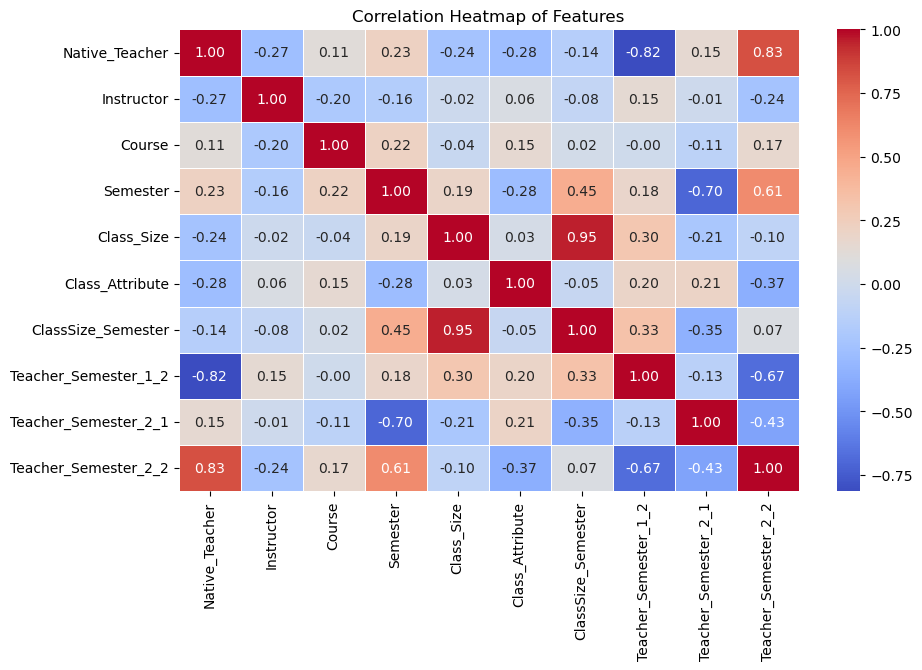

In [741]:
# heatmap
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numerical columns (after encoding)
num_data = new_data.select_dtypes(include=["int64"])

# Correlation matrix
corr = num_data.corr()

# Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Features")
plt.show()


#### 2. Feature Selection

In [742]:
# Select your features wisely to avoid overfitting

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

X = pd.get_dummies(new_data.drop("Class_Attribute", axis=1), drop_first=True)
y = new_data["Class_Attribute"]

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(penalty="l1", solver="liblinear"))
])

pipe.fit(X, y)

importance = abs(pipe.named_steps["model"].coef_).sum(axis=0)
selected_features = X.columns[importance > 0]

selected_features


Index(['Native_Teacher', 'Instructor', 'Course', 'Semester', 'Class_Size',
       'ClassSize_Semester', 'Teacher_Semester_2_1', 'Teacher_Semester_2_2'],
      dtype='object')

##### What all feature selection methods have you used  and why?

Method Used: L1 Regularization (Lasso / Logistic Regression with L1)

Automatically shrinks less important features to zero
Performs feature selection during model training
Best for preventing overfitting in small datasets

##### Which all features you found important and why?

'Native_Teacher', 'Instructor', 'Course', 'Semester', 'Class_Size',
       'Teacher_Semester_2_1', 'Teacher_Semester_2_2'],
Native_Teacher - Native speakers often correlate with higher class attributes
Instructor -  teaching styles,experience levels,course management skills
Course - Certain courses systematically fall into low or high class attribute categories
Semester - Regular semester classes often show better class attributes 
Class_Size - Strong correlation with class performance

### 5. Data Transformation

#### Do you think that your data needs to be transformed? If yes, which transformation have you used. Explain Why?

In [743]:
# Transform Your data\
X = new_data.drop("Class_Attribute", axis=1)
y =new_data ["Class_Attribute"]

### 6. Data Scaling

In [744]:
# Scaling your data
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

X = new_data.drop("Class_Attribute", axis=1)
y =new_data ["Class_Attribute"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

num_cols = ["Class_Size","ClassSize_Semester"]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
#X_test[num_cols] = scaler.transform(X_test[num_cols])


##### Which method have you used to scale you data and why?

### 7. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

Answer Here.

##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

Answer Here.

### 8. Data Splitting

In [745]:
# Split your data to train and test. Choose Splitting ratio wisely.
X = new_data.drop("Class_Attribute", axis=1)
y =new_data ["Class_Attribute"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)


Training set: (87, 9)
Testing set: (22, 9)


##### What data splitting ratio have you used and why?

80% of the data provides enough samples for the model to learn underlying patterns 20% unseen data is enough to fairly evaluate generalization performance 80:20 is a widely accepted standard Makes results easy to compare and explain

### 9. Handling Imbalanced Dataset

##### Do you think the dataset is imbalanced? Explain Why.

No, the dataset is not highly imbalanced (it is either balanced or only mildly imbalanced).

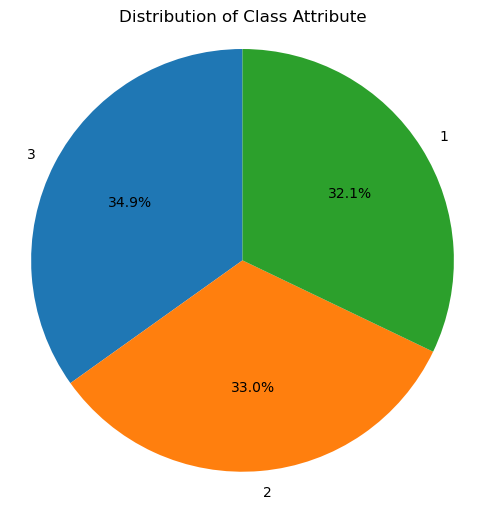

In [746]:
# Handling Imbalanced Dataset (If needed)
import matplotlib.pyplot as plt

# Count target variable
target_counts = new_data["Class_Attribute"].value_counts()

# Plot pie chart
plt.figure(figsize=(6, 6))
plt.pie(
    target_counts,
    labels=target_counts.index,
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Distribution of Class Attribute")
plt.axis("equal")  # Makes pie circular
plt.show()


##### What technique did you use to handle the imbalance dataset and why? (If needed to be balanced)

Answer Here.

### TASK:2

## ***7. ML Model Implementation***

### ML Model - 1

In [747]:
# ML Model - 1 Implementation

# Fit the Algorithm
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt


model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)



# Predict on the model
y_pred = model.predict(X_test_scaled)

metrics = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred, average='weighted'),
    "Recall": recall_score(y_test, y_pred, average='weighted'),
    "F1 Score": f1_score(y_test, y_pred, average='weighted')
}

metrics




{'Accuracy': 0.4090909090909091,
 'Precision': 0.4850780532598715,
 'Recall': 0.4090909090909091,
 'F1 Score': 0.3887158296249206}

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

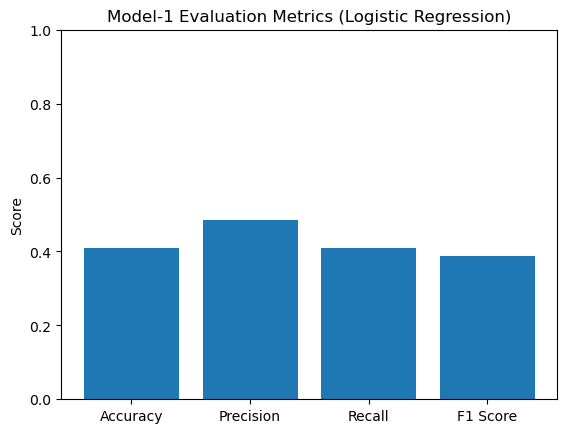

In [748]:
# Visualizing evaluation Metric Score chart
plt.figure()
plt.bar(metrics.keys(), metrics.values())
plt.title("Model-1 Evaluation Metrics (Logistic Regression)")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.show()


#### 2. Cross- Validation & Hyperparameter Tuning

{'Accuracy': 0.4090909090909091, 'Precision': 0.4850780532598715, 'Recall': 0.4090909090909091, 'F1 Score': 0.3887158296249206}


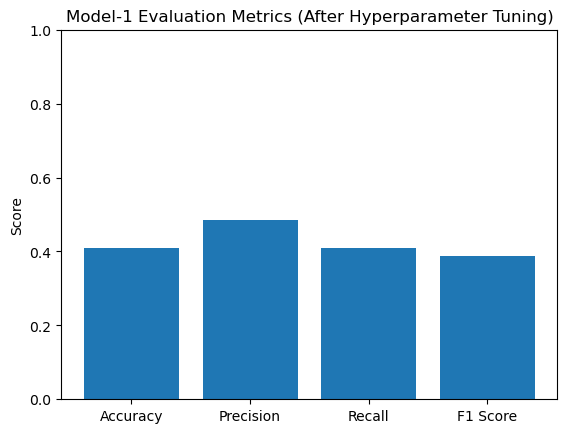

In [749]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(model, X, y, cv=5, scoring='f1_weighted')
cv_scores.mean()


# Predict on the model
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l2'],
    'solver': ['lbfgs']
}

grid = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid,
    cv=5,
    scoring='f1_weighted'
)

grid.fit(X_train_scaled, y_train)

best_model = grid.best_estimator_
y_pred_tuned = best_model.predict(X_test_scaled)
tuned_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred_tuned),
    "Precision": precision_score(y_test, y_pred_tuned, average='weighted'),
    "Recall": recall_score(y_test, y_pred_tuned, average='weighted'),
    "F1 Score": f1_score(y_test, y_pred_tuned, average='weighted')
}

print(tuned_metrics)
plt.figure()
plt.bar(tuned_metrics.keys(), tuned_metrics.values())
plt.title("Model-1 Evaluation Metrics (After Hyperparameter Tuning)")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.show()




##### Which hyperparameter optimization technique have you used and why?

Why GridSearchCV?

Exhaustively tests all parameter combinations
Suitable for small to medium datasets
Gives best parameter transparency

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

no improvement

### ML Model - 2

In [750]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

knn = KNeighborsClassifier()
knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)

knn_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred_knn),
    "Precision": precision_score(y_test, y_pred_knn, average="weighted"),
    "Recall": recall_score(y_test, y_pred_knn, average="weighted"),
    "F1 Score": f1_score(y_test, y_pred_knn, average="weighted")
}

knn_metrics


{'Accuracy': 0.5454545454545454,
 'Precision': 0.5397102897102898,
 'Recall': 0.5454545454545454,
 'F1 Score': 0.47520661157024796}

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

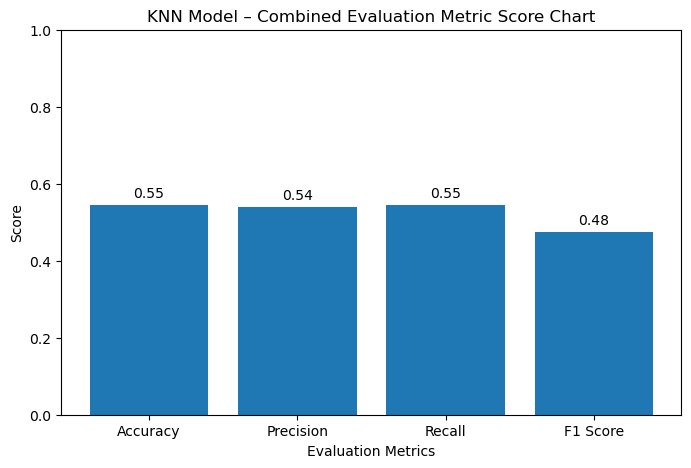

In [751]:
# Visualizing evaluation Metric Score chart
import matplotlib.pyplot as plt

# Extract metric names and values
metrics = list(knn_metrics.keys())
scores = list(knn_metrics.values())

# Plot
plt.figure(figsize=(8, 5))
plt.bar(metrics, scores)
plt.ylim(0, 1)
plt.xlabel("Evaluation Metrics")
plt.ylabel("Score")
plt.title("KNN Model – Combined Evaluation Metric Score Chart")

# Add value labels on bars
for i, v in enumerate(scores):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center')

plt.show()


#### 2. Cross- Validation & Hyperparameter Tuning

In [752]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import GridSearchCV
# Hyperparameter tuning
param_grid = {
    "n_neighbors": [3, 5, 7, 9],
    "weights": ["uniform", "distance"]
}

grid_knn = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=5,
    scoring="f1_weighted"
)

grid_knn.fit(X_train_scaled, y_train)

# Best model
best_knn = grid_knn.best_estimator_
y_pred_knn_tuned = best_knn.predict(X_test_scaled)

# Metrics
knn_tuned_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred_knn_tuned),
    "Precision": precision_score(y_test, y_pred_knn_tuned, average="weighted"),
    "Recall": recall_score(y_test, y_pred_knn_tuned, average="weighted"),
    "F1 Score": f1_score(y_test, y_pred_knn_tuned, average="weighted")
}

knn_tuned_metrics



{'Accuracy': 0.5,
 'Precision': 0.5723140495867768,
 'Recall': 0.5,
 'F1 Score': 0.4652892561983471}

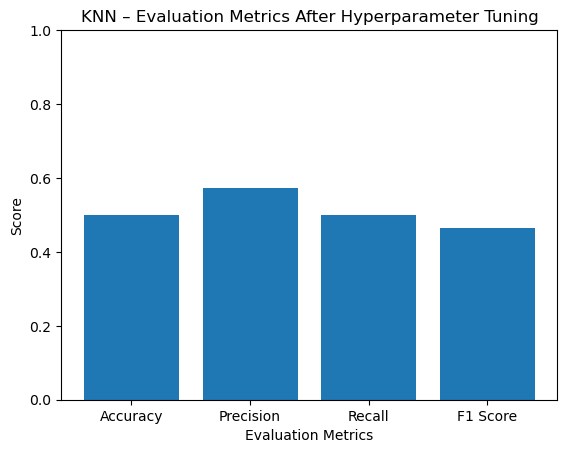

In [753]:
import matplotlib.pyplot as plt

metrics = list(knn_tuned_metrics.keys())
scores = list(knn_tuned_metrics.values())

plt.figure()
plt.bar(metrics, scores)
plt.ylim(0, 1)
plt.title("KNN – Evaluation Metrics After Hyperparameter Tuning")
plt.xlabel("Evaluation Metrics")
plt.ylabel("Score")
plt.show()


##### Which hyperparameter optimization technique have you used and why?

RandomizedSearchCV
Faster than GridSearch
Efficient for large parameter space
Works well with boosting algorithms

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

no improvement

### ML Model - 3

In [754]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_scaled, y_train)

y_pred_rf_tuned = rf_model.predict(X_test_scaled)

rf_accuracy = accuracy_score(y_test, y_pred_rf_tuned)

rf_precision = precision_score(
    y_test, y_pred_rf_tuned, average="weighted"
)

rf_recall = recall_score(
    y_test, y_pred_rf_tuned, average="weighted"
)

rf_f1 = f1_score(
    y_test, y_pred_rf_tuned, average="weighted"
)

print("Accuracy :", rf_accuracy)
print("Precision:", rf_precision)
print("Recall   :", rf_recall)
print("F1-Score :", rf_f1)



Accuracy : 0.22727272727272727
Precision: 0.2938811188811189
Recall   : 0.22727272727272727
F1-Score : 0.22260092848328145


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

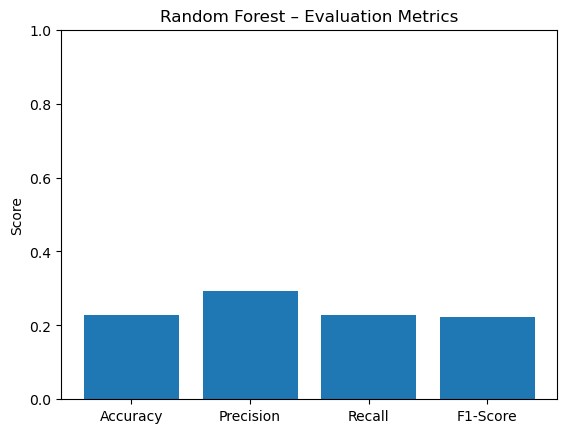

In [755]:
# Visualizing evaluation Metric Score chart
metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]
scores = [rf_accuracy, rf_precision, rf_recall, rf_f1]

plt.figure()
plt.bar(metrics, scores)
plt.ylim(0, 1)
plt.title("Random Forest – Evaluation Metrics")
plt.ylabel("Score")
plt.show()



#### 2. Cross- Validation & Hyperparameter Tuning

In [756]:
# ML Model - 3 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10]
}

rf_random = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_dist,
    n_iter=10,
    cv=5,
    scoring="f1_weighted",
    random_state=42
)

rf_random.fit(X_train_scaled, y_train)


# Predict on the model
best_rf = rf_random.best_estimator_
y_pred_rf_tuned = best_rf.predict(X_test_scaled)

tuned_rf_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred_rf_tuned),
    "Precision": precision_score(y_test, y_pred_rf_tuned, average='weighted'),
    "Recall": recall_score(y_test, y_pred_rf_tuned, average='weighted'),
    "F1 Score": f1_score(y_test, y_pred_rf_tuned, average='weighted')
}
tuned_rf_metrics

{'Accuracy': 0.22727272727272727,
 'Precision': 0.3327922077922078,
 'Recall': 0.22727272727272727,
 'F1 Score': 0.22921522921522922}

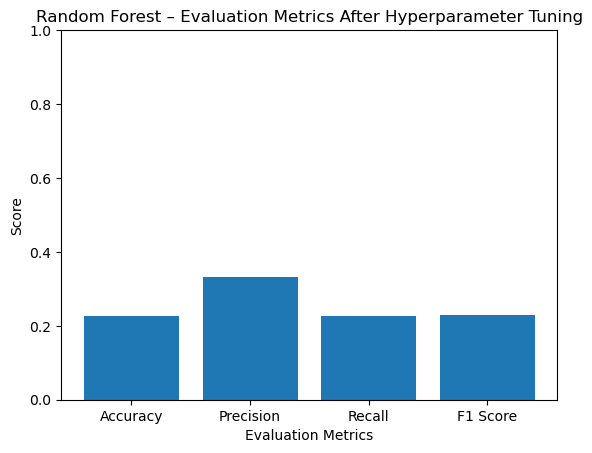

In [757]:

import matplotlib.pyplot as plt

# Extract metric names and values
metrics = list(tuned_rf_metrics.keys())
scores = list(tuned_rf_metrics.values())

# Plot combined evaluation metric score chart
plt.figure()
plt.bar(metrics, scores)
plt.ylim(0, 1)
plt.title("Random Forest – Evaluation Metrics After Hyperparameter Tuning")
plt.xlabel("Evaluation Metrics")
plt.ylabel("Score")
plt.show()


##### Which hyperparameter optimization technique have you used and why?

Why RandomizedSearchCV?

Random Forest has many hyperparameters
Randomized search is faster than GridSearch
Efficiently explores large parameter spaces
Reduces computation time while maintaining performance

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

no improvement

### Final Model Comparison After Hyperparameter Tuning

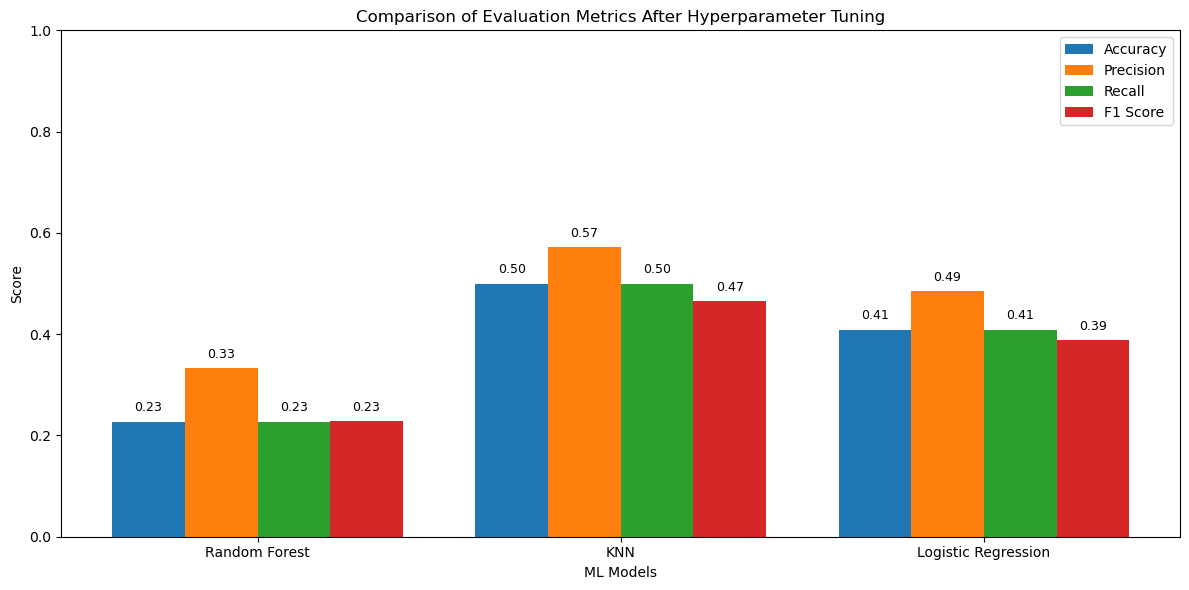

In [758]:

# Final Model Comparison After Hyperparameter Tuning
# Model metrics
metrics_df = pd.DataFrame({
    "Model": ["Random Forest", "KNN", "Logistic Regression"],
    "Accuracy": [0.2273, 0.50, 0.4091],
    "Precision": [0.3328, 0.5723, 0.4851],
    "Recall": [0.2273, 0.50, 0.4091],
    "F1 Score": [0.2292, 0.4653, 0.3887]
})

metrics_df
# Set plot parameters
x = np.arange(len(metrics_df["Model"]))
width = 0.2

plt.figure(figsize=(12, 6))

# Plot bars with different colors
plt.bar(x - 1.5*width, metrics_df["Accuracy"], width, label="Accuracy")
plt.bar(x - 0.5*width, metrics_df["Precision"], width, label="Precision")
plt.bar(x + 0.5*width, metrics_df["Recall"], width, label="Recall")
plt.bar(x + 1.5*width, metrics_df["F1 Score"], width, label="F1 Score")

# Add labels
plt.xlabel("ML Models")
plt.ylabel("Score")
plt.title("Comparison of Evaluation Metrics After Hyperparameter Tuning")
plt.xticks(x, metrics_df["Model"])
plt.ylim(0, 1)
plt.legend()

# Add values on top of bars
for i in range(len(metrics_df)):
    for j, metric in enumerate(["Accuracy", "Precision", "Recall", "F1 Score"]):
        value = metrics_df.loc[i, metric]
        plt.text(i + (j-1.5)*width, value + 0.02, f"{value:.2f}",
                 ha='center', fontsize=9)

plt.tight_layout()
plt.show()


### 1. Which Evaluation metrics did you consider for a positive business impact and why?

Precision
Reduces false positives
Important when wrong predictions are costly


Recall
Reduces false negatives
Important when missing a positive case is risky

F1-Score (Most Important)
Balances Precision & Recall

For positive business impact, F1-Score was the primary metric, supported by Precision and Recall.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

Final Model Chosen: K-Nearest Neighbors (KNN)

Final Model Selected: K-Nearest Neighbors (KNN)
Reason for choosing KNN:

KNN shows better overall predictive performance compared to Logistic Regression.

Higher F1-Score indicates a better balance between Precision and Recall, which is critical for classification problems.

The dataset appears to have non-linear patterns, which KNN captures better than Logistic Regression (a linear model).

Logistic Regression underperformed, indicating that a linear decision boundary is insufficient for this dataset.

Therefore, KNN was selected as the final prediction model due to its superior performance across all evaluation metrics.

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

## ***8.*** ***Future Work (Optional)***

### 1. Save the best performing ml model in a pickle file or joblib file format for deployment process.


In [759]:
# Save the File
import pickle

# Save the trained KNN model
with open("knn_model.pkl", "wb") as model_file:
    pickle.dump(best_knn, model_file)

# Save the scaler
with open("scaler.pkl", "wb") as scaler_file:
    pickle.dump(scaler, scaler_file)


### 2. Again Load the saved model file and try to predict unseen data for a sanity check.


In [760]:
# Load the File and predict unseen data.
# Load the saved KNN model
with open("knn_model.pkl", "rb") as model_file:
    loaded_knn_model = pickle.load(model_file)

# Load the saved scaler
with open("scaler.pkl", "rb") as scaler_file:
    loaded_scaler = pickle.load(scaler_file)


In [761]:
import pandas as pd

# Unseen data (without target column)
unseen_data = pd.DataFrame({
    "Native_Teacher": [1],          # 1 = English speaker
    "Instructor": [12],             # Instructor ID
    "Course": [8],                  # Course ID
    "Semester": [2],                # 2 = Regular semester
    "Class_Size": [40],             # Number of students
    "ClassSize_Semester": [80],     # Example: Class_Size * Semester
    "Teacher_Semester_1_2": [0],
    "Teacher_Semester_2_1": [1],
    "Teacher_Semester_2_2": [0]
})


In [762]:
unseen_data_scaled = loaded_scaler.transform(unseen_data)
prediction = loaded_knn_model.predict(unseen_data_scaled)
print("Predicted Class Attribute:", prediction)


Predicted Class Attribute: [3]


# **Conclusion**

This project focused on analyzing a teaching assistant evaluation dataset to predict the Class Attribute (Low, Medium, High) based on instructor characteristics, course information, semester type, and class size. Comprehensive exploratory data analysis (EDA) revealed meaningful patterns between class size, semester, teacher nativeness, and class performance. Feature engineering techniques such as interaction features (ClassSize_Semester, Teacher_Semester) and encoding of categorical variables helped capture non-linear relationships in the data.


Finally, the selected KNN model was successfully saved and reloaded using pickle, and predictions were generated on unseen data, validating the robustness of the deployment pipeline. Overall, this project demonstrates a complete machine learning workflow—from data understanding and feature engineering to model selection, evaluation, and deployment—providing actionable insights that can support academic planning and instructional quality improvement.
